In [27]:
#packages
import numpy as np
import matplotlib.pyplot as plt
from utils import*

%matplotlib inline

In [43]:
#implementing K-means
#1. finding the closest centroids
def find_closest_centroids(X, centroids):
    '''
    Computes the centroid memberships for every example

    Args: 
        X (ndarray): (m,n) input values
        centroids (ndarray) : (K, n) centroids

    Returns:
        idx (array_like) : (m, ) closest centroids
    '''
    #set K
    K = centroids.shape[0]
    idx = np.zeros(X.shape[0], dtype=int)

    for i in range(X.shape[0]):
        #array to hold the distance between X[i] and each centroids[j]
        distance = []
        for j in range(centroids.shape[0]):
            #calculate the norm btw (X[i] - centroids[j])
            norm_ij = np.linalg.norm(X[i] - centroids[j])
            distance.append(norm_ij)
        idx[i]= np.argmin(distance) # calculate the index of minimum value in distance

    return idx

In [44]:
#examine the above implementation
#load dataset
X = load_data()

In [45]:
#examine the data set
print('First five elements of X are: \n', X[:5])
print('The shape of X is: ', X.shape)

First five elements of X are: 
 [[1.84207953 4.6075716 ]
 [5.65858312 4.79996405]
 [6.35257892 3.2908545 ]
 [2.90401653 4.61220411]
 [3.23197916 4.93989405]]
The shape of X is:  (300, 2)


In [46]:
#select an initial set of centroids (3 centroids)
initial_centroids = np.array([[3,3], [6,2], [8,5]])

#find the closest centroids using initial_centroids
idx = find_closest_centroids(X, initial_centroids)

#print the closest centroids for the first three elements
print('First three elements in idx are: ', idx[:3])

First three elements in idx are:  [0 2 1]


In [47]:
#unit test
from public_tests import *
find_closest_centroids_test(find_closest_centroids)

All tests passed!


In [50]:
#computing centroid mean
def compute_centroids(X, idx, K):
    '''
    Returns the new centroids by computing the means of the data points 
     assigned to each centroid

    Args:
        X (ndarray): (m,n) data points
        idx (ndarray) : (m,)Array containing index of closest centroid for each example
                        in X. Concretely, idx[i] contains the index of the 
                        centroid closest to example i
        K (int): number of centroids
    
    Returns:
        centroids (ndarray): (K,n) New centroids computed
     '''

    m, n = X.shape
    centroids = np.zeros((K,n))

    for k in range(K):
        #list all data points in X assigned to centroid k
        points = X[idx == k]
        #mean of points assigned
        centroids[k] = np.mean(points, axis = 0)
    
    return centroids

In [51]:
#confirm the above implementation
K = 3
centroids = compute_centroids(X, idx, K)

print('The centroids are: ', centroids)

The centroids are:  [[2.42830111 3.15792418]
 [5.81350331 2.63365645]
 [7.11938687 3.6166844 ]]


In [53]:
#unit test
compute_centroids_test(compute_centroids)

All tests passed!


In [ ]:
#2.  2D dataset sample for K-means 
def run_kMeans(X, initial_centroids, max_iters=10, plot_progress=False):
    '''
    Runs the K-Means algot=rithm on data matrix X, where each row of X 
        is a single example
    '''
    #initialize values
    m,n = X.shape
    K = initial_centroids.shape[0]
    centroids = initial_centroids
    previous_centroids = centroids
    idx = np.zeros(m),
    plt.figure(figsize=(8,6))

    #run K-Means
    for i in range(max_iters):

        #output progress
        print('K-Means iteration %d /%d' % (i, max_iters - 1))

        #for each example in X, assign it to the closest centroid
        idx = find_closest_centroids(X, centroids)

        #plot progress
        if plot_progress:
            plot_progress_kMeans(X, centroids, previous_centroids, idx, K, i)
            previous_centroids = centroids

        #Given the memberships, compute new centroids
        centroids = compute_centroids(X, idx, K)
    plt.show()
    return centroids, idx

K-Means iteration 0 /9
K-Means iteration 1 /9
K-Means iteration 2 /9
K-Means iteration 3 /9
K-Means iteration 4 /9
K-Means iteration 5 /9
K-Means iteration 6 /9
K-Means iteration 7 /9
K-Means iteration 8 /9
K-Means iteration 9 /9


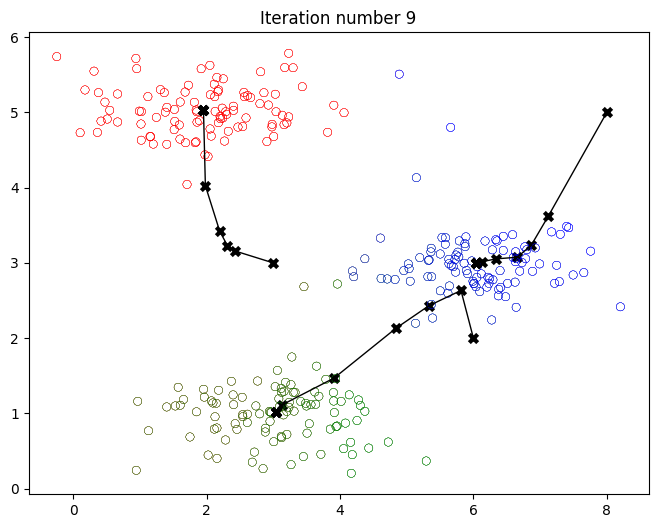

In [57]:
#load an example data set
X = load_data()

#set the initial centroids
initial_centroids = np.array([[3,3],[6,2],[8,5]])

#number of iterations
max_iters = 10

#run K-Means
centroids, idx = run_kMeans(X, initial_centroids, max_iters, plot_progress=True)

In [ ]:
#3. RANDOM INITIALIZATION
''' 
1. The code first randomly shuffles the indices of the examples (using np.random.permutation()).
2. Then, it selects the first  𝐾
   examples based on the random permutation of the indices.
3. This allows the examples to be selected at random without the risk of selecting the same example twice
'''


In [58]:
def kMeans_init_centroids(X, K):
    ''' 
    This function initializes K centroids that are to be used in K-Means 
     on the data set

    Args:
        X (ndarray): Data points
        K (int) : Number of centroids/clusters

    Returns:
        centroids (ndarray) : initilized centroids
    '''
    #randomly re-order the indices of examples
    randidx = np.random.permutation(X.shape[0])

    #take the first K examples as centroids
    centroids = X[randidx[:K]]

    return centroids


K-Means iteration 0 /9
K-Means iteration 1 /9
K-Means iteration 2 /9
K-Means iteration 3 /9
K-Means iteration 4 /9
K-Means iteration 5 /9
K-Means iteration 6 /9
K-Means iteration 7 /9
K-Means iteration 8 /9
K-Means iteration 9 /9


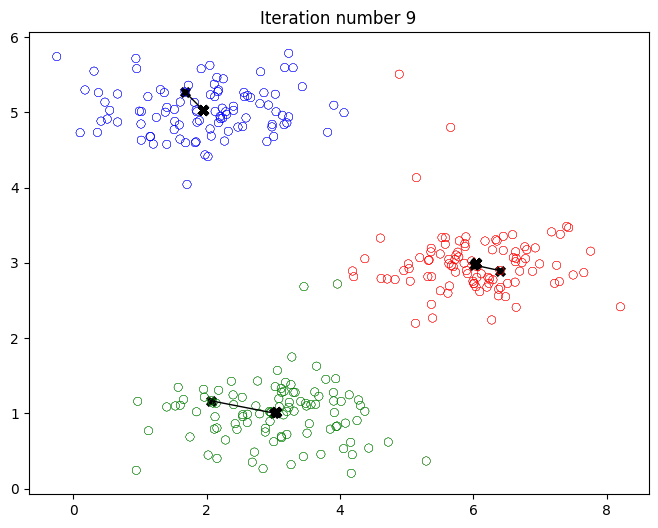

In [61]:
#implementation testing - run several times
#set number of centroids and max of iterations
K = 3
max_iters = 10

#Set initial centroids by picking random examples from the dataset
initial_centroids = kMeans_init_centroids(X,K)

#run K-Means
centroids, idx = run_kMeans(X, initial_centroids, max_iters, plot_progress=True)

In [ ]:
#4. IMAGE COMPTRESSION
''' 
1. Concretely, you will treat every pixel in the original image as a data example 
     and use the K-means algorithm to find the 16 colors that best group (cluster) the pixels
     in the 3- dimensional RGB space.
2. Once you have computed the cluster centroids on the image, you will then use the 
  16 colors to replace the pixels in the original image
'''

In [63]:
#Dataset
#Load image
original_img = plt.imread('./images/bird_small.png')


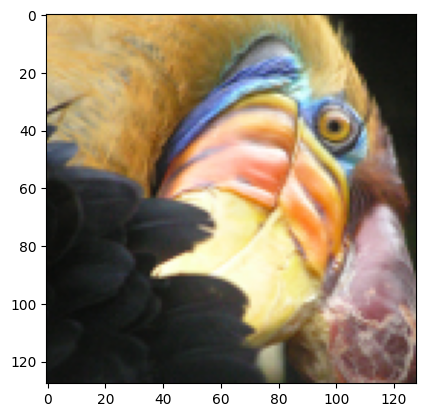

In [64]:
#visualize the image
plt.imshow(original_img)

In [65]:
#check dimensions
print('Shape of the original_img is: ', original_img.shape)

Shape of the original_img is:  (128, 128, 3)


In [ ]:
#observation - creates a 3D matrix
#1. the first two indices identify a pixel position, and
#2. the thoird index represents red, green, or blue

In [67]:
#Processing data
#Divide by 255 so that all values are in the range 0-1(not needed for PNG files)
#original_img = original_img / 255
#Reshape the image into a m * 3 matrix where m = number of pixels
#( in this case m = 128 * 128 = 16384)
#Each row will contain the Red, Green, and Blue pixel values
# This gives us our dataset matrix X_img that we will use K-Means on

X_img = np.reshape(original_img, (original_img.shape[0] * original_img.shape[1], 3))



In [73]:
#K-Means on image pixels
#Try different values of k and max_iters here
K = 16
max_iters = 10

#Using the function you have omplemented above
initial_centroids = kMeans_init_centroids(X_img, K)

#Run K-Means - this can take a while depending on K and max_iters
centroids, idx= run_kMeans(X_img, initial_centroids, max_iters)


K-Means iteration 0 /9
K-Means iteration 1 /9
K-Means iteration 2 /9
K-Means iteration 3 /9
K-Means iteration 4 /9
K-Means iteration 5 /9
K-Means iteration 6 /9
K-Means iteration 7 /9
K-Means iteration 8 /9
K-Means iteration 9 /9


<Figure size 800x600 with 0 Axes>

In [74]:
print('Shape of idx: ', idx.shape)
print('Closest centroid for the first five elements: ', idx[:5])

Shape of idx:  (16384,)
Closest centroid for the first five elements:  [7 7 7 7 7]


In [ ]:
#plot the colors of the image and mark the centroids
plot_kMeans_RGB(X_img, centroids, idx, K)

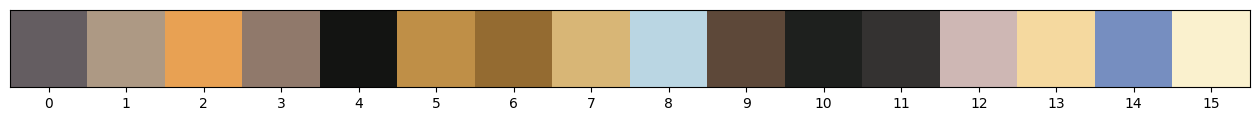

In [77]:
#visualize 16 colors selected
show_centroid_colors(centroids)

In [79]:
#compress the image
# find the closest centroid of each pixel
idx = find_closest_centroids(X_img, centroids)

#replace each pixel with the color of the closest centroid
X_recovered = centroids[idx, :]

#reshape image into proper dimensions
X_recovered = np.reshape(X_recovered, original_img.shape)

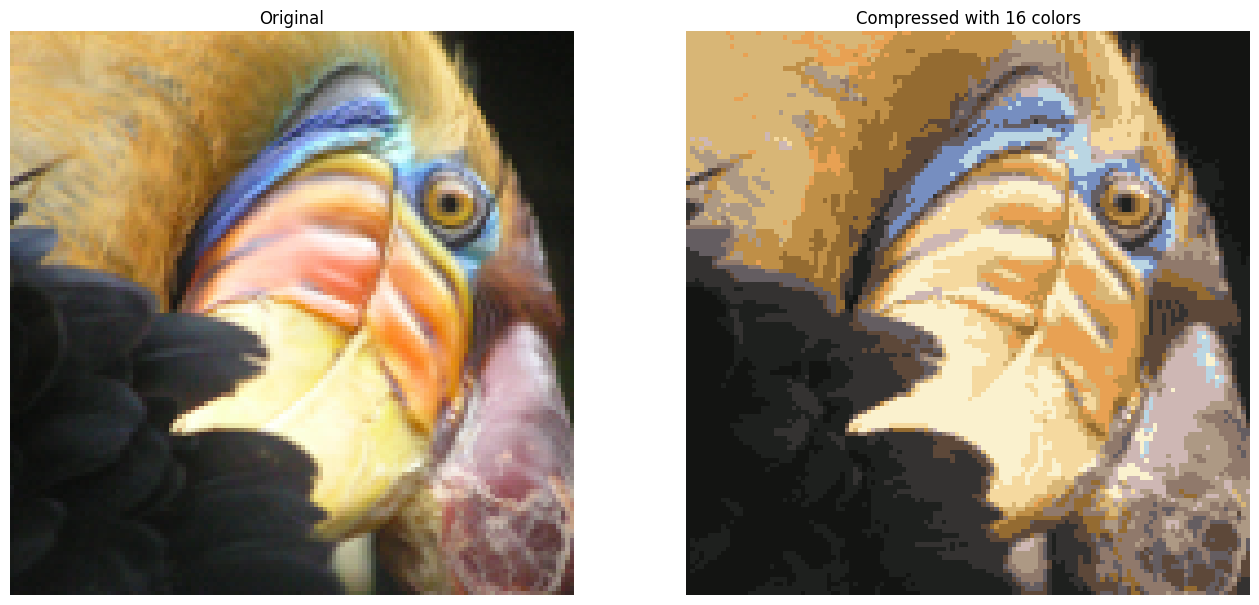

In [81]:
#view effecs of the compression
#display original image
fig, ax = plt.subplots(1, 2, figsize=(16,16))
plt.axis('off')

ax[0].imshow(original_img)
ax[0].set_title('Original')
ax[0].set_axis_off()

#display compressed iamge
ax[1].imshow(X_recovered)
ax[1].set_title('Compressed with %d colors' %K)
ax[1].set_axis_off()

In [ ]:
#Disclaimer - (Bird image-from coursera course) The provided photo used in 
# this exercise belongs to Frank Wouters and is used with his permission